<a href="https://colab.research.google.com/github/fernandofilgueiras-ctrl/Conectividade-das-escolas/blob/main/C%C3%B3pia_de_MVP_Impacto_da_conectividade_das_escolas_no_IDEB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Pipeline: Conectividade Escolar × Qualidade da Educação

| Fonte | Método | Período |
|-------|--------|---------|
| Microdados Censo Escolar (INEP) | Download automático | 2017–2025 |
| IDEB por Município – Anos Iniciais e Finais | Upload manual (planilhas limpas) | 2015–2023 |

**Arquitetura:** Bronze → Prata → Ouro → EDA → Forecasting 2035

Resumo: Este script realiza uma análise de dados de ponta a ponta para investigar se a conectividade digital das escolas brasileiras contribui para a melhoria da qualidade da educação. O pipeline começa extraindo duas fontes oficiais do INEP: os microdados do Censo Escolar (anos 2017 a 2024), de onde se obtêm indicadores como acesso à internet, banda larga, laboratório de informática e disponibilidade de computadores para alunos, e os resultados do IDEB (anos 2015 a 2023), que medem a qualidade do ensino básico. Os dados passam por uma arquitetura Medallion em três camadas — Bronze (dados brutos persistidos), Silver (dados limpos, tipados e padronizados, com criação de um Índice de Conectividade composto) e Gold (agregações por município, UF e região, com cruzamento entre conectividade e IDEB). Em cada camada, gráficos inline são gerados para permitir inspeção visual progressiva: barras de volume, histogramas, boxplots, heatmaps, violinplots e gráficos radar. Com os dados preparados, o script executa uma análise exploratória que inclui scatter plots com linhas de tendência, análise de correlação de Pearson, comparações urbana versus rural e evolução pareada das duas variáveis ao longo do tempo. Em seguida, realiza uma etapa de forecasting: ajusta um modelo de regressão linear entre conectividade e IDEB, projeta a evolução da conectividade até 2030 usando uma curva logística e simula três cenários — pessimista (estagnação), moderado (tendência atual) e otimista (investimento forte em universalização).

---
## 1. Instalação e Imports

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels prophet openpyxl requests tqdm plotly pyarrow

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mticker
import matplotlib.patches as mpatches, seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os, zipfile, requests, gc
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
from prophet import Prophet

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis', font_scale=1.2)
plt.rcParams.update({'figure.figsize': (14,7), 'figure.dpi': 100})
print('✅ Bibliotecas prontas!')

✅ Bibliotecas prontas!


In [ ]:
# === DIRETÓRIOS ===
BASE = '/content/pipeline_educacao'
for d in ['raw','bronze','silver','gold','output']:
    os.makedirs(f'{BASE}/{d}', exist_ok=True)
RAW, BRONZE, SILVER, GOLD, OUT = [f'{BASE}/{d}' for d in ['raw','bronze','silver','gold','output']]

ANOS_CENSO = [2017,2018,2019,2020,2021,2022,2023,2024,2025]
ANOS_IDEB  = [2015,2017,2019,2021,2023]

URLS_CENSO = {a: f'https://download.inep.gov.br/dados_abertos/microdados_censo_escolar_{a}{"_" if a==2025 else ""}.zip' for a in ANOS_CENSO}
COLS_ID = ['CO_ENTIDADE','CO_MUNICIPIO','NO_MUNICIPIO','CO_UF','SG_UF','TP_DEPENDENCIA','TP_LOCALIZACAO','TP_SITUACAO_FUNCIONAMENTO']
COLS_CONECT = ['IN_INTERNET','IN_BANDA_LARGA','IN_INTERNET_APRENDIZAGEM','IN_COMPUTADOR','IN_DESKTOP_ALUNO','IN_COMP_PORTATIL_ALUNO','IN_TABLET_ALUNO','IN_LABORATORIO_INFORMATICA']
print('📂 Diretórios OK')

📂 Diretórios OK


---
## 2. ETL — Censo Escolar (Download Automático)
⚠️ ZIPs de ~500 MB–2 GB cada.

In [ ]:
def download_arquivo(url, destino, desc=''):
    try:
        print(f'  ⬇️ {url}')
        r = requests.get(url, stream=True, timeout=60); r.raise_for_status()
        total = int(r.headers.get('content-length',0))
        print(f'  📦 {total/(1024**2):.0f} MB')
        with open(destino,'wb') as f:
            baixado = 0
            for chunk in r.iter_content(chunk_size=131072):
                f.write(chunk); baixado += len(chunk)
                if total: print(f'\r  {desc}: {baixado/total*100:.1f}%', end='')
        print('\n  ✅ OK'); return True
    except Exception as e:
        print(f'  ❌ {e}')
        if os.path.exists(destino): os.remove(destino)
        return False

def encontrar_csv_escolas(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        nomes = z.namelist()
        cands = [n for n in nomes if n.upper().endswith('.CSV') and 'ESCOLA' in n.upper()
                 and not any(x in n.upper() for x in ['TURMA','MATRIC','DOCENT','GESTOR','ALUNO'])]
        if cands:
            cands.sort(key=lambda n: z.getinfo(n).file_size, reverse=True)
            return cands[0]
        csvs = [(n, z.getinfo(n).file_size) for n in nomes if n.upper().endswith('.CSV')]
        return sorted(csvs, key=lambda x: x[1], reverse=True)[0][0] if csvs else None

def detectar_csv(zip_path, csv_nome):
    with zipfile.ZipFile(zip_path) as z:
        with z.open(csv_nome) as f:
            for enc in ['latin-1','utf-8','cp1252']:
                for sep in [';',',','|']:
                    try:
                        f.seek(0)
                        h = pd.read_csv(f, nrows=0, encoding=enc, sep=sep)
                        if len(h.columns)>10: return enc, sep, h.columns.tolist()
                    except: pass
    return 'latin-1',';',[]

def extrair_conectividade(zip_path, ano):
    csv_nome = encontrar_csv_escolas(zip_path)
    if not csv_nome: print('  ❌ CSV não encontrado'); return None
    print(f'  📄 {csv_nome}')
    enc, sep, cols_disp = detectar_csv(zip_path, csv_nome)
    cols_usar = [c for c in COLS_ID+COLS_CONECT if c in cols_disp]
    extras = [c for c in ['IN_INTERNET_ALUNOS','QT_COMPUTADOR','QT_COMP_ALUNO'] if c in cols_disp]
    cols_usar += extras
    cols_con = [c for c in COLS_CONECT if c in cols_disp]
    if not cols_con: print('  ❌ Sem colunas de conectividade'); return None
    print(f'  🔌 Conectividade: {cols_con}')
    chunks = []
    with zipfile.ZipFile(zip_path) as z:
        with z.open(csv_nome) as f:
            for ch in pd.read_csv(f, encoding=enc, sep=sep, usecols=cols_usar, chunksize=50000, low_memory=False):
                if 'TP_SITUACAO_FUNCIONAMENTO' in ch.columns:
                    ch = ch[ch['TP_SITUACAO_FUNCIONAMENTO']==1]
                chunks.append(ch)
    df = pd.concat(chunks, ignore_index=True); df['NU_ANO_CENSO'] = ano
    print(f'  ✅ {len(df):,} escolas'); return df

In [ ]:
# === DOWNLOAD E EXTRAÇÃO DO CENSO ESCOLAR ===
censo_dfs, anos_ok, anos_fail = [], [], []
for ano in ANOS_CENSO:
    print(f'\n{"="*60}\n  CENSO ESCOLAR {ano}\n{"="*60}')
    pq = f'{BRONZE}/censo_{ano}.parquet'
    if os.path.exists(pq):
        print(f'  ♻️ Já processado'); censo_dfs.append(pd.read_parquet(pq)); anos_ok.append(ano); continue
    zp = f'{RAW}/censo_{ano}.zip'
    if not os.path.exists(zp):
        if not download_arquivo(URLS_CENSO[ano], zp, f'Censo {ano}'): anos_fail.append(ano); continue
    try:
        df = extrair_conectividade(zp, ano)
        if df is not None and len(df)>0:
            df.to_parquet(pq, index=False); censo_dfs.append(df); anos_ok.append(ano)
            if os.path.exists(zp): os.remove(zp); print('  🗑️ ZIP removido')
        else: anos_fail.append(ano)
    except Exception as e: print(f'  ❌ {e}'); anos_fail.append(ano)
    gc.collect()

df_censo = pd.concat(censo_dfs, ignore_index=True) if censo_dfs else pd.DataFrame()
print(f'\n✅ Censo: {len(df_censo):,} registros | Anos OK: {anos_ok}')
if anos_fail: print(f'⚠️ Falhas: {anos_fail}')


  CENSO ESCOLAR 2017
  ⬇️ https://download.inep.gov.br/dados_abertos/microdados_censo_escolar_2017.zip
  📦 25 MB
  Censo 2017: 100.0%
  ✅ OK
  📄 microdados_ed_basica_2017/dados/microdados_ed_basica_2017.csv
  🔌 Conectividade: ['IN_INTERNET', 'IN_BANDA_LARGA', 'IN_INTERNET_APRENDIZAGEM', 'IN_COMPUTADOR', 'IN_DESKTOP_ALUNO', 'IN_COMP_PORTATIL_ALUNO', 'IN_TABLET_ALUNO', 'IN_LABORATORIO_INFORMATICA']
  ✅ 185,925 escolas
  🗑️ ZIP removido

  CENSO ESCOLAR 2018
  ⬇️ https://download.inep.gov.br/dados_abertos/microdados_censo_escolar_2018.zip
  📦 25 MB
  Censo 2018: 100.0%
  ✅ OK
  📄 microdados_ed_basica_2018/dados/microdados_ed_basica_2018.csv
  🔌 Conectividade: ['IN_INTERNET', 'IN_BANDA_LARGA', 'IN_INTERNET_APRENDIZAGEM', 'IN_COMPUTADOR', 'IN_DESKTOP_ALUNO', 'IN_COMP_PORTATIL_ALUNO', 'IN_TABLET_ALUNO', 'IN_LABORATORIO_INFORMATICA']
  ✅ 183,746 escolas
  🗑️ ZIP removido

  CENSO ESCOLAR 2019
  ⬇️ https://download.inep.gov.br/dados_abertos/microdados_censo_escolar_2019.zip
  📦 25 MB
  Censo 

---
## 3. ETL — IDEB (Upload das Planilhas)
Faça upload das duas planilhas:
- `divulgacao_anos_iniciais_municipios_2023.xlsx`
- `divulgacao_anos_finais_municipios_2023.xlsx`

As planilhas estão disponíveis no GitHub. Tentei de toda forma possível fazer a raspagem na tabela de divulgação do INEP mas sempre dava erro.

In [ ]:
from google.colab import files
print('📤 Faça upload das 2 planilhas do IDEB (Anos Iniciais e Anos Finais):')
uploaded = files.upload()
for nome in uploaded:
    destino = os.path.join(RAW, nome)
    with open(destino, 'wb') as f:
        f.write(uploaded[nome])
    print(f'  ✅ Salvo em {destino} ({len(uploaded[nome])/(1024**2):.1f} MB)')

📤 Faça upload das 2 planilhas do IDEB (Anos Iniciais e Anos Finais):


Saving divulgacao_anos_finais_municipios_2023.xlsx to divulgacao_anos_finais_municipios_2023.xlsx
Saving divulgacao_anos_iniciais_municipios_2023.xlsx to divulgacao_anos_iniciais_municipios_2023 (1).xlsx
  ✅ Salvo em /content/pipeline_educacao/raw/divulgacao_anos_finais_municipios_2023.xlsx (10.2 MB)
  ✅ Salvo em /content/pipeline_educacao/raw/divulgacao_anos_iniciais_municipios_2023 (1).xlsx (10.7 MB)


In [ ]:
def ler_ideb_planilha(caminho, etapa, ideb_cols_idx):
    """
    Lê planilha do IDEB com a estrutura real do INEP.
    - Linhas 0–3: cabeçalhos multi-nível → skiprows=4
    - Col 0: SG_UF | Col 1: CO_MUNICIPIO | Col 2: NO_MUNICIPIO | Col 3: REDE
    - ideb_cols_idx: dict {ano: índice_coluna} para os IDEB observados
    """
    print(f'\n📊 Lendo IDEB {etapa}: {caminho}')
    df = pd.read_excel(caminho, header=None, skiprows=4)
    print(f'   {len(df):,} linhas × {df.shape[1]} colunas')

    resultado = pd.DataFrame()
    resultado['SG_UF'] = df.iloc[:, 0].astype(str)
    resultado['CO_MUNICIPIO'] = pd.to_numeric(df.iloc[:, 1], errors='coerce')
    resultado['NO_MUNICIPIO'] = df.iloc[:, 2].astype(str)
    resultado['REDE'] = df.iloc[:, 3].astype(str)

    for ano, idx in ideb_cols_idx.items():
        resultado[f'IDEB_{ano}'] = pd.to_numeric(df.iloc[:, idx], errors='coerce')

    # Limpar
    resultado = resultado.dropna(subset=['CO_MUNICIPIO'])
    resultado['CO_MUNICIPIO'] = resultado['CO_MUNICIPIO'].astype(int)
    resultado = resultado[(resultado['CO_MUNICIPIO'] > 1000000) & (resultado['CO_MUNICIPIO'] < 9999999)]

    # Filtrar apenas rede "Pública" (ou Total, se disponível) para não duplicar
    # Se há Municipal e Estadual separados, pegar "Pública" como agregado
    if 'Pública' in resultado['REDE'].values:
        resultado = resultado[resultado['REDE'] == 'Pública']
        print(f'   Filtrado rede Pública: {len(resultado):,} municípios')
    else:
        resultado = resultado.drop_duplicates(subset=['CO_MUNICIPIO'], keep='first')

    # Wide → Long
    id_vars = ['SG_UF', 'CO_MUNICIPIO', 'NO_MUNICIPIO', 'REDE']
    value_vars = [f'IDEB_{a}' for a in ideb_cols_idx.keys()]
    df_long = resultado.melt(id_vars=id_vars, value_vars=value_vars,
                              var_name='ANO_VAR', value_name='VL_IDEB')
    df_long['ANO_IDEB'] = df_long['ANO_VAR'].str.extract(r'(\d{4})').astype(int)
    df_long['ETAPA'] = etapa
    df_long = df_long.drop(columns=['ANO_VAR']).dropna(subset=['VL_IDEB'])
    df_long['CO_UF'] = (df_long['CO_MUNICIPIO'] // 100000).astype(int)

    print(f'   ✅ {len(df_long):,} registros | {df_long["CO_MUNICIPIO"].nunique():,} municípios')
    print(f'   IDEB médio: {df_long["VL_IDEB"].mean():.2f} (min {df_long["VL_IDEB"].min():.1f}, max {df_long["VL_IDEB"].max():.1f})')
    return df_long


# Colunas do IDEB observado por posição (conferidas na inspeção dos arquivos)
# Anos Iniciais: 122 colunas → IDEB em cols 109–113
IDEB_COLS_AI = {2015: 109, 2017: 110, 2019: 111, 2021: 112, 2023: 113}
# Anos Finais: 112 colunas → IDEB em cols 99–103
IDEB_COLS_AF = {2015: 99, 2017: 100, 2019: 101, 2021: 102, 2023: 103}

# Localizar arquivos
arq_ai = os.path.join(RAW, 'divulgacao_anos_iniciais_municipios_2023.xlsx')
arq_af = os.path.join(RAW, 'divulgacao_anos_finais_municipios_2023.xlsx')

df_ideb_ai = ler_ideb_planilha(arq_ai, 'Anos Iniciais', IDEB_COLS_AI)
df_ideb_af = ler_ideb_planilha(arq_af, 'Anos Finais', IDEB_COLS_AF)

# Combinar
df_ideb = pd.concat([df_ideb_ai, df_ideb_af], ignore_index=True)
print(f'\n🎯 IDEB Total: {len(df_ideb):,} registros (AI + AF)')
display(df_ideb.head(10))


📊 Lendo IDEB Anos Iniciais: /content/pipeline_educacao/raw/divulgacao_anos_iniciais_municipios_2023.xlsx
   14,514 linhas × 122 colunas
   Filtrado rede Pública: 5,566 municípios
   ✅ 26,679 registros | 5,546 municípios
   IDEB médio: 5.62 (min 2.3, max 10.0)

📊 Lendo IDEB Anos Finais: /content/pipeline_educacao/raw/divulgacao_anos_finais_municipios_2023.xlsx
   14,417 linhas × 112 colunas
   Filtrado rede Pública: 5,568 municípios
   ✅ 26,185 registros | 5,561 municípios
   IDEB médio: 4.56 (min 1.8, max 9.3)

🎯 IDEB Total: 52,864 registros (AI + AF)


,SG_UF,CO_MUNICIPIO,NO_MUNICIPIO,REDE,VL_IDEB,ANO_IDEB,ETAPA,CO_UF
0,RO,1100015,Alta Floresta D'Oeste,Pública,5.8,2015,Anos Iniciais,11
1,RO,1100023,Ariquemes,Pública,5.2,2015,Anos Iniciais,11
2,RO,1100031,Cabixi,Pública,5.5,2015,Anos Iniciais,11
3,RO,1100049,Cacoal,Pública,5.9,2015,Anos Iniciais,11
4,RO,1100056,Cerejeiras,Pública,5.9,2015,Anos Iniciais,11
5,RO,1100064,Colorado do Oeste,Pública,6.3,2015,Anos Iniciais,11
6,RO,1100072,Corumbiara,Pública,5.2,2015,Anos Iniciais,11
7,RO,1100080,Costa Marques,Pública,4.9,2015,Anos Iniciais,11
8,RO,1100098,Espigão D'Oeste,Pública,6.0,2015,Anos Iniciais,11
9,RO,1100106,Guajará-Mirim,Pública,4.9,2015,Anos Iniciais,11


In [ ]:
assert len(df_censo)>0, 'ERRO: Sem dados do Censo'
assert len(df_ideb)>0, 'ERRO: Sem dados do IDEB'
print(f'✅ Censo: {len(df_censo):,} registros | IDEB: {len(df_ideb):,} registros')

✅ Censo: 1,639,642 registros | IDEB: 52,864 registros


---
## 4. Camada Bronze

In [ ]:
df_censo.to_parquet(f'{BRONZE}/censo_bronze.parquet', index=False)
df_ideb.to_parquet(f'{BRONZE}/ideb_bronze.parquet', index=False)
print(f'📦 Bronze salva!')
display(df_censo.head(3))
display(df_ideb.head(3))

📦 Bronze salva!


,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,CO_ENTIDADE,TP_DEPENDENCIA,TP_LOCALIZACAO,TP_SITUACAO_FUNCIONAMENTO,IN_LABORATORIO_INFORMATICA,IN_COMPUTADOR,QT_COMP_ALUNO,IN_DESKTOP_ALUNO,IN_COMP_PORTATIL_ALUNO,IN_TABLET_ALUNO,QT_COMPUTADOR,IN_INTERNET,IN_INTERNET_ALUNOS,IN_INTERNET_APRENDIZAGEM,IN_BANDA_LARGA,NU_ANO_CENSO
0,RO,11,Alta Floresta D'Oeste,1100015,11022558,2,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017
1,RO,11,Alta Floresta D'Oeste,1100015,11024275,2,1,1,1.0,1.0,18.0,0.0,0.0,0.0,39.0,1.0,0.0,0.0,1.0,2017
2,RO,11,Alta Floresta D'Oeste,1100015,11024291,3,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017


,SG_UF,CO_MUNICIPIO,NO_MUNICIPIO,REDE,VL_IDEB,ANO_IDEB,ETAPA,CO_UF
0,RO,1100015,Alta Floresta D'Oeste,Pública,5.8,2015,Anos Iniciais,11
1,RO,1100023,Ariquemes,Pública,5.2,2015,Anos Iniciais,11
2,RO,1100031,Cabixi,Pública,5.5,2015,Anos Iniciais,11


---
## 5. Camada Prata — Limpeza

In [ ]:
# === PRATA CENSO ===
print('=== Limpeza Censo ===')
dfc = df_censo.copy()
n0 = len(dfc)
dfc = dfc.drop_duplicates(subset=['CO_ENTIDADE','NU_ANO_CENSO'], keep='last')
print(f'Duplicatas: {n0-len(dfc):,}')
if 'TP_SITUACAO_FUNCIONAMENTO' in dfc.columns:
    dfc = dfc[dfc['TP_SITUACAO_FUNCIONAMENTO']==1]
for c in [c for c in dfc.columns if c.startswith('IN_')]:
    dfc[c] = dfc[c].fillna(0).astype(int)
dfc['CO_MUNICIPIO'] = pd.to_numeric(dfc['CO_MUNICIPIO'], errors='coerce')
dfc = dfc.dropna(subset=['CO_MUNICIPIO'])
dfc['CO_MUNICIPIO'] = dfc['CO_MUNICIPIO'].astype(int)
if 'CO_UF' not in dfc.columns or dfc['CO_UF'].isna().all():
    dfc['CO_UF'] = (dfc['CO_MUNICIPIO']//100000).astype(int)
ind = [c for c in ['IN_INTERNET','IN_BANDA_LARGA','IN_LABORATORIO_INFORMATICA','IN_COMPUTADOR'] if c in dfc.columns]
dfc['SCORE_CONECT'] = dfc[ind].sum(axis=1) / len(ind)
dfc['DS_DEP'] = dfc['TP_DEPENDENCIA'].map({1:'Federal',2:'Estadual',3:'Municipal',4:'Privada'})
dfc['DS_LOC'] = dfc['TP_LOCALIZACAO'].map({1:'Urbana',2:'Rural'})
print(f'✅ Prata Censo: {len(dfc):,}')

# === PRATA IDEB ===
print('\n=== Limpeza IDEB ===')
dfi = df_ideb.copy()
dfi = dfi.drop_duplicates(subset=['CO_MUNICIPIO','ANO_IDEB','ETAPA'], keep='last')
dfi = dfi[(dfi['VL_IDEB']>=0)&(dfi['VL_IDEB']<=10)]
dfi = dfi.sort_values(['CO_MUNICIPIO','ETAPA','ANO_IDEB'])
dfi['IDEB_ANT'] = dfi.groupby(['CO_MUNICIPIO','ETAPA'])['VL_IDEB'].shift(1)
dfi['VAR_IDEB'] = dfi['VL_IDEB'] - dfi['IDEB_ANT']
print(f'✅ Prata IDEB: {len(dfi):,}')

dfc.to_parquet(f'{SILVER}/censo_prata.parquet', index=False)
dfi.to_parquet(f'{SILVER}/ideb_prata.parquet', index=False)

=== Limpeza Censo ===
Duplicatas: 0
✅ Prata Censo: 1,639,642

=== Limpeza IDEB ===
✅ Prata IDEB: 52,864


---
## 6. Camada Ouro — Agregação e Join

In [ ]:
# Agregar Censo por município × ano
agg = {'CO_ENTIDADE':'count'}
for c in ['IN_INTERNET','IN_BANDA_LARGA','IN_LABORATORIO_INFORMATICA','IN_COMPUTADOR','SCORE_CONECT']:
    if c in dfc.columns: agg[c] = 'mean'
g_censo = dfc.groupby(['CO_MUNICIPIO','NU_ANO_CENSO','CO_UF']).agg(agg).reset_index()
g_censo = g_censo.rename(columns={'CO_ENTIDADE':'QT_ESCOLAS','IN_INTERNET':'PCT_INTERNET',
    'IN_BANDA_LARGA':'PCT_BL','IN_LABORATORIO_INFORMATICA':'PCT_LAB','IN_COMPUTADOR':'PCT_COMP',
    'SCORE_CONECT':'SCORE_CONECT_MED'})

# Mapear ano do Censo → IDEB
def map_ideb(a):
    for x in reversed(sorted(ANOS_IDEB)):
        if x <= a: return x
    return ANOS_IDEB[0]
g_censo['ANO_IDEB'] = g_censo['NU_ANO_CENSO'].apply(map_ideb)

# IDEB médio (AI + AF) por município × ano
ideb_medio = dfi.groupby(['CO_MUNICIPIO','ANO_IDEB']).agg(
    VL_IDEB=('VL_IDEB','mean'), VAR_IDEB=('VAR_IDEB','mean')
).reset_index()

# JOIN
gold = g_censo.merge(ideb_medio, on=['CO_MUNICIPIO','ANO_IDEB'], how='inner')
def regiao(uf):
    if uf<20: return 'Norte'
    if uf<30: return 'Nordeste'
    if uf<40: return 'Sudeste'
    if uf<50: return 'Sul'
    return 'Centro-Oeste'
gold['REGIAO'] = gold['CO_UF'].apply(regiao)

# Tabelas auxiliares
gold_nac = gold.groupby('NU_ANO_CENSO').agg(
    PCT_INTERNET=('PCT_INTERNET','mean'), PCT_BL=('PCT_BL','mean'),
    SCORE=('SCORE_CONECT_MED','mean'), VL_IDEB=('VL_IDEB','mean'),
    QT_ESC=('QT_ESCOLAS','sum'), N_MUN=('CO_MUNICIPIO','nunique')
).reset_index()

gold_reg = gold.groupby(['REGIAO','NU_ANO_CENSO']).agg(
    PCT_INTERNET=('PCT_INTERNET','mean'), PCT_BL=('PCT_BL','mean'),
    SCORE=('SCORE_CONECT_MED','mean'), VL_IDEB=('VL_IDEB','mean')
).reset_index()

# Também por etapa
gold_etapa = dfi.groupby(['ANO_IDEB','ETAPA'])['VL_IDEB'].mean().reset_index()

gold.to_parquet(f'{GOLD}/gold.parquet', index=False)
gold.to_csv(f'{GOLD}/gold.csv', index=False)

print(f'🥇 Ouro: {len(gold):,} registros | {gold["CO_MUNICIPIO"].nunique():,} municípios')
print(f'   Anos Censo: {sorted(gold["NU_ANO_CENSO"].unique())}')
display(gold_nac)

🥇 Ouro: 49,357 registros | 5,564 municípios
   Anos Censo: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,NU_ANO_CENSO,PCT_INTERNET,PCT_BL,SCORE,VL_IDEB,QT_ESC,N_MUN
0,2017,0.713449,0.542037,0.624801,4.990516,185529,5546
1,2018,0.754821,0.583984,0.646777,4.990516,183357,5546
2,2019,0.791323,0.675414,0.670189,5.180147,181794,5513
3,2020,0.824675,0.658129,0.675352,5.180147,180613,5513
4,2021,0.861297,0.689458,0.689571,5.212155,176665,5323
5,2022,0.899535,0.746538,0.707719,5.212155,180916,5323
6,2023,0.931465,0.776350,0.726200,5.299051,179760,5531
7,2024,0.942875,0.786831,0.733705,5.299051,180587,5531
8,2025,0.962259,0.818151,0.740693,5.299051,180053,5531


---
## 7. Análise Exploratória (EDA)

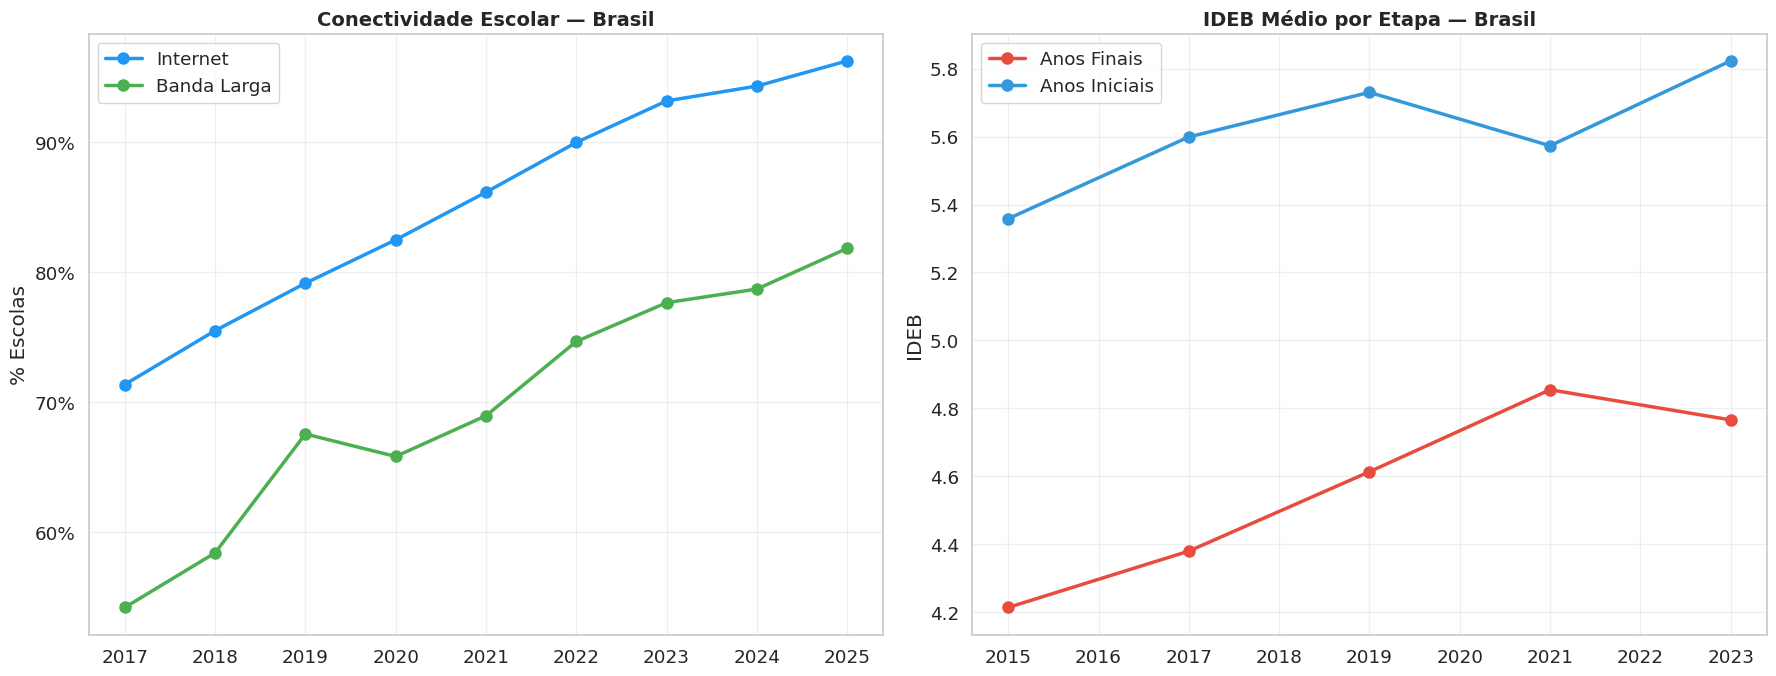

In [ ]:
# G1: Evolução Conectividade + IDEB
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(18,7))
for c,l,cor in [('PCT_INTERNET','Internet','#2196F3'),('PCT_BL','Banda Larga','#4CAF50'),
                ('PCT_LAB','Lab Info','#FF9800'),('PCT_COMP','Computador','#9C27B0')]:
    if c in gold_nac.columns:
        ax1.plot(gold_nac['NU_ANO_CENSO'], gold_nac[c]*100, 'o-', lw=2.5, label=l, color=cor, ms=8)
ax1.set_title('Conectividade Escolar — Brasil', fontsize=14, fontweight='bold')
ax1.set_ylabel('% Escolas'); ax1.legend(); ax1.grid(alpha=.3)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:.0f}%'))

# IDEB por etapa
cores_e = {'Anos Iniciais':'#3498db','Anos Finais':'#e74c3c'}
for et in gold_etapa['ETAPA'].unique():
    d = gold_etapa[gold_etapa['ETAPA']==et]
    ax2.plot(d['ANO_IDEB'], d['VL_IDEB'], 'o-', lw=2.5, label=et, color=cores_e.get(et,'gray'), ms=8)
ax2.set_title('IDEB Médio por Etapa — Brasil', fontsize=14, fontweight='bold')
ax2.set_ylabel('IDEB'); ax2.legend(); ax2.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/g01_evolucao.png', dpi=150, bbox_inches='tight'); plt.show()

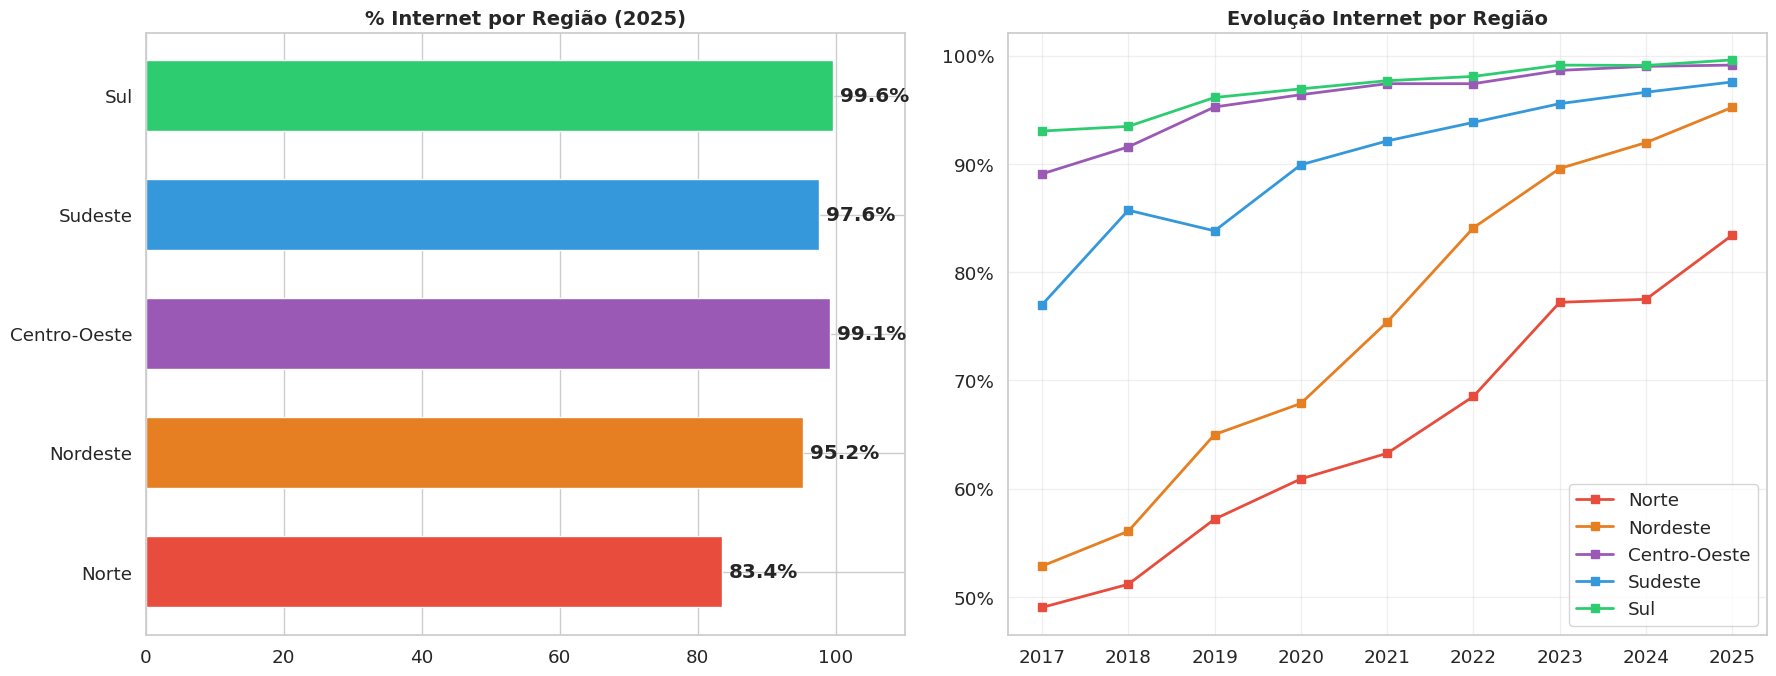

In [ ]:
# G2: Conectividade por Região
ordem = ['Norte','Nordeste','Centro-Oeste','Sudeste','Sul']
cr = {'Norte':'#e74c3c','Nordeste':'#e67e22','Sudeste':'#3498db','Sul':'#2ecc71','Centro-Oeste':'#9b59b6'}
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(18,7))

ua = gold_reg['NU_ANO_CENSO'].max()
du = gold_reg[gold_reg['NU_ANO_CENSO']==ua].set_index('REGIAO').reindex(ordem)
bars = ax1.barh(du.index, du['PCT_INTERNET']*100, color=[cr[r] for r in du.index], height=.6)
for b,v in zip(bars, du['PCT_INTERNET']*100):
    ax1.text(b.get_width()+1, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontweight='bold')
ax1.set_title(f'% Internet por Região ({ua})', fontsize=14, fontweight='bold'); ax1.set_xlim(0,110)

for r in ordem:
    d = gold_reg[gold_reg['REGIAO']==r]
    ax2.plot(d['NU_ANO_CENSO'], d['PCT_INTERNET']*100, 's-', lw=2, label=r, color=cr[r])
ax2.set_title('Evolução Internet por Região', fontsize=14, fontweight='bold')
ax2.legend(); ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:.0f}%'))
ax2.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/g02_regiao.png', dpi=150, bbox_inches='tight'); plt.show()

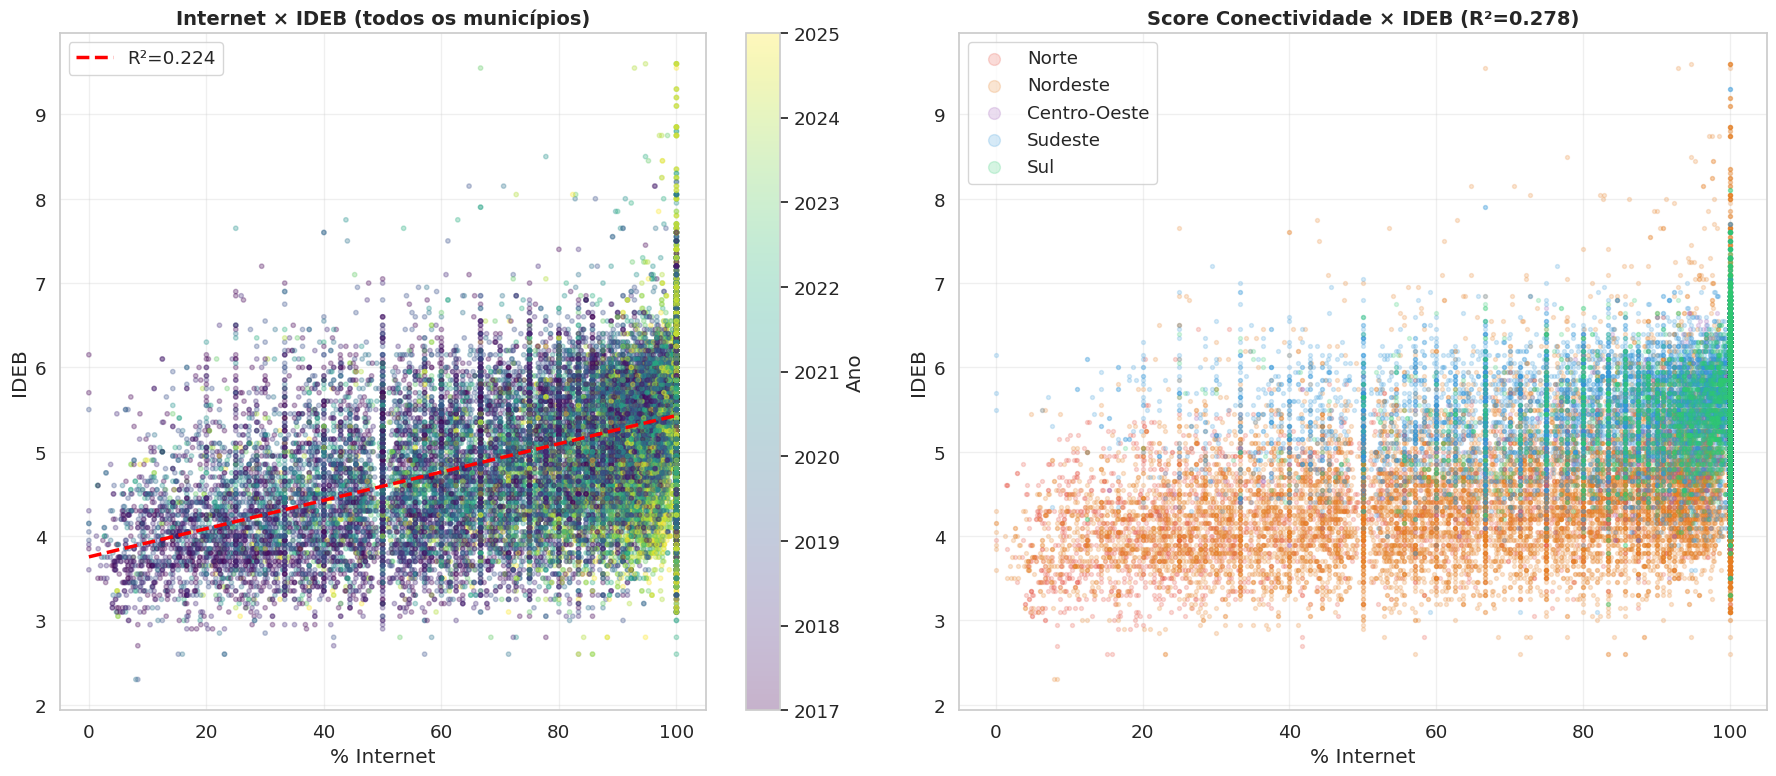

In [ ]:
# G3: Scatter — Internet × IDEB com regressão
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(18,8))
x,y = gold['PCT_INTERNET'].values*100, gold['VL_IDEB'].values
m = ~(np.isnan(x)|np.isnan(y))
sc = ax1.scatter(x[m], y[m], c=gold.loc[m.nonzero()[0],'NU_ANO_CENSO'], cmap='viridis', alpha=.3, s=10)
lr = LinearRegression().fit(x[m].reshape(-1,1), y[m])
xl = np.linspace(x[m].min(), x[m].max(), 100)
ax1.plot(xl, lr.predict(xl.reshape(-1,1)), 'r--', lw=2.5, label=f'R²={lr.score(x[m].reshape(-1,1),y[m]):.3f}')
plt.colorbar(sc, ax=ax1, label='Ano')
ax1.set_title('Internet × IDEB (todos os municípios)', fontsize=14, fontweight='bold')
ax1.set_xlabel('% Internet'); ax1.set_ylabel('IDEB'); ax1.legend(); ax1.grid(alpha=.3)

# Por região
for r in ordem:
    d = gold[gold['REGIAO']==r]
    ax2.scatter(d['PCT_INTERNET']*100, d['VL_IDEB'], alpha=.2, s=8, color=cr[r], label=r)
x2,y2 = gold['SCORE_CONECT_MED'].values*100, y
m2 = ~(np.isnan(x2)|np.isnan(y2))
lr2 = LinearRegression().fit(x2[m2].reshape(-1,1), y2[m2])
ax2.set_title(f'Score Conectividade × IDEB (R²={lr2.score(x2[m2].reshape(-1,1),y2[m2]):.3f})', fontsize=14, fontweight='bold')
ax2.set_xlabel('% Internet'); ax2.set_ylabel('IDEB')
ax2.legend(markerscale=3); ax2.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/g03_scatter.png', dpi=150, bbox_inches='tight'); plt.show()

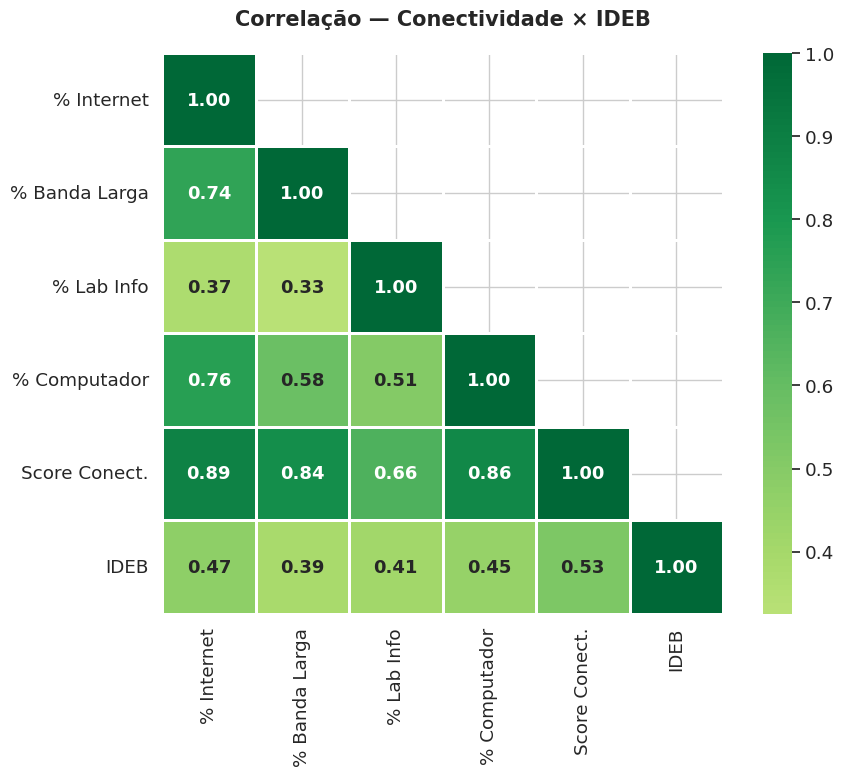

In [ ]:
# G4: Heatmap de correlação
fig, ax = plt.subplots(figsize=(10,8))
cc = [c for c in ['PCT_INTERNET','PCT_BL','PCT_LAB','PCT_COMP','SCORE_CONECT_MED','VL_IDEB'] if c in gold.columns]
lb = {'PCT_INTERNET':'% Internet','PCT_BL':'% Banda Larga','PCT_LAB':'% Lab Info',
      'PCT_COMP':'% Computador','SCORE_CONECT_MED':'Score Conect.','VL_IDEB':'IDEB'}
cm = gold[cc].corr(); cm.index = [lb.get(c,c) for c in cm.index]; cm.columns = cm.index
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdYlGn', center=0, mask=mask, square=True,
            linewidths=2, ax=ax, annot_kws={'size':13,'fontweight':'bold'})
ax.set_title('Correlação — Conectividade × IDEB', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout(); plt.savefig(f'{OUT}/g04_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

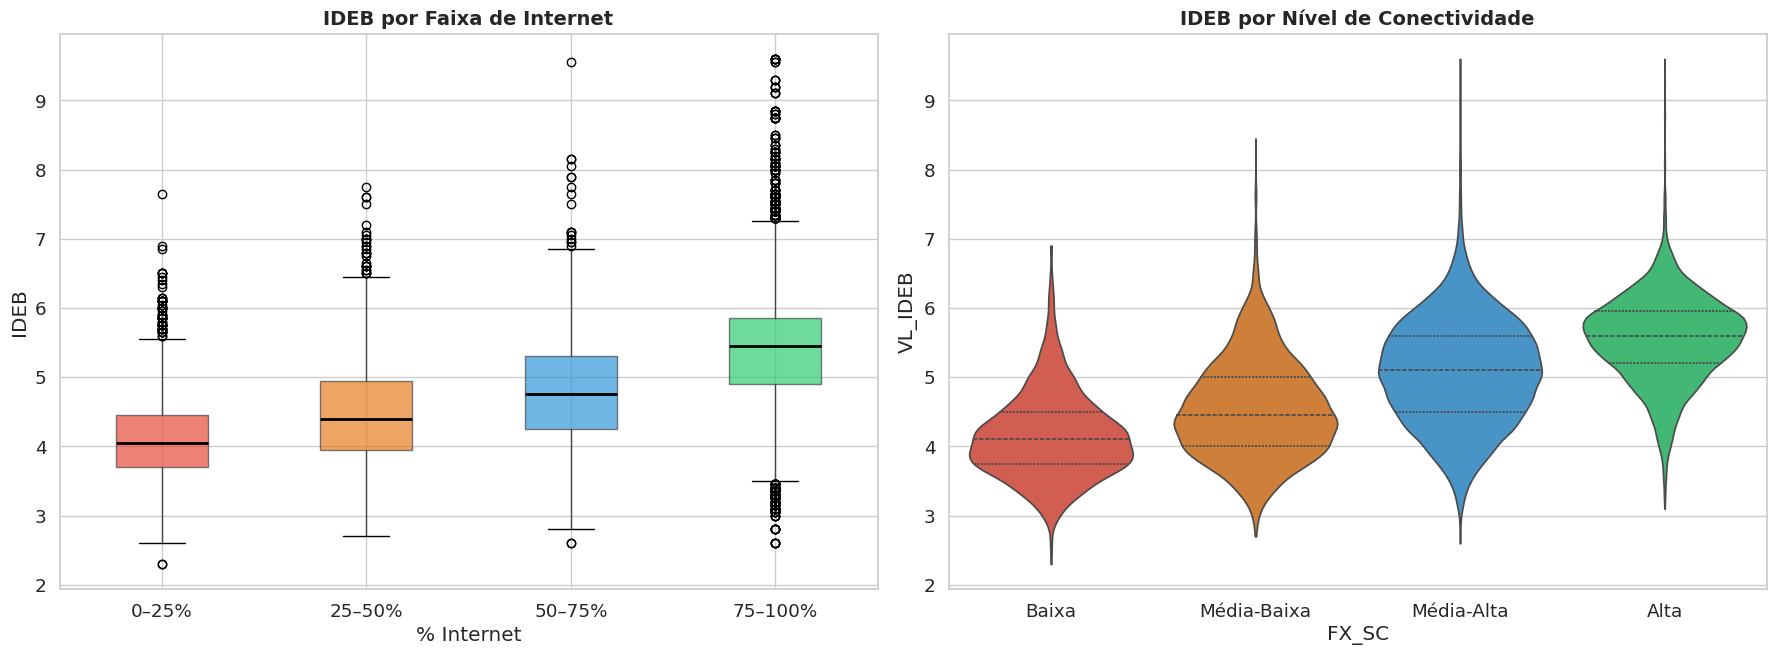

In [ ]:
# G5: Box + Violin por faixa de conectividade
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(18,7))
gold['FX_INT'] = pd.cut(gold['PCT_INTERNET'], bins=[0,.25,.50,.75,1.01],
    labels=['0–25%','25–50%','50–75%','75–100%'], include_lowest=True)
cfx = ['#e74c3c','#e67e22','#3498db','#2ecc71']
bp = gold.boxplot('VL_IDEB', by='FX_INT', ax=ax1, patch_artist=True, return_type='dict',
                  medianprops=dict(color='black',lw=2))
for p,c in zip(bp['VL_IDEB']['boxes'], cfx): p.set_facecolor(c); p.set_alpha(.7)
ax1.set_title('IDEB por Faixa de Internet', fontsize=14, fontweight='bold')
ax1.set_xlabel('% Internet'); ax1.set_ylabel('IDEB'); plt.suptitle('')

gold['FX_SC'] = pd.cut(gold['SCORE_CONECT_MED'], bins=[0,.25,.50,.75,1.01],
    labels=['Baixa','Média-Baixa','Média-Alta','Alta'], include_lowest=True)
pal = {'Baixa':'#e74c3c','Média-Baixa':'#e67e22','Média-Alta':'#3498db','Alta':'#2ecc71'}
sns.violinplot(data=gold, x='FX_SC', y='VL_IDEB', palette=pal, ax=ax2, inner='quartile', cut=0)
ax2.set_title('IDEB por Nível de Conectividade', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{OUT}/g05_box.png', dpi=150, bbox_inches='tight'); plt.show()

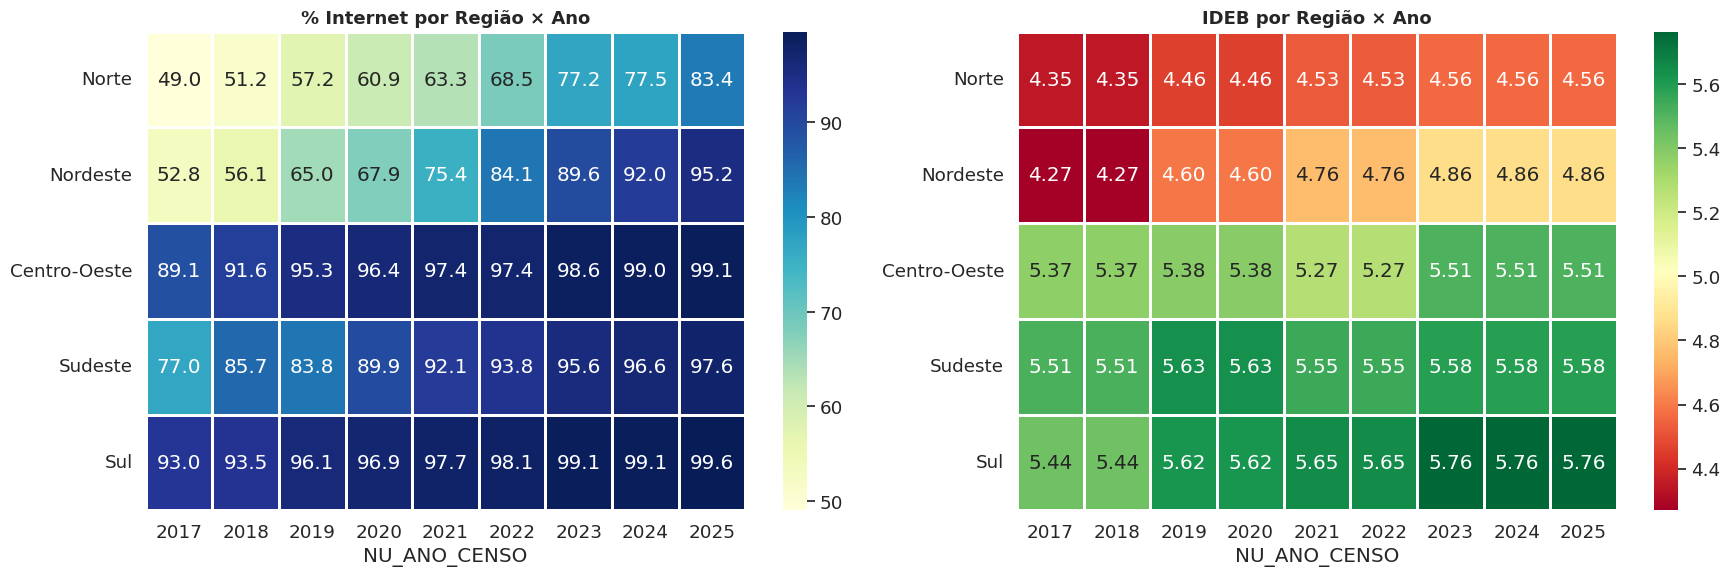

In [ ]:
# G6: Heatmap Temporal — Internet e IDEB por Região × Ano
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(18,6))
pi = gold_reg.pivot_table('PCT_INTERNET','REGIAO','NU_ANO_CENSO').reindex(ordem)*100
sns.heatmap(pi, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax1, linewidths=1)
ax1.set_title('% Internet por Região × Ano', fontsize=13, fontweight='bold'); ax1.set_ylabel('')
pid = gold_reg.pivot_table('VL_IDEB','REGIAO','NU_ANO_CENSO').reindex(ordem)
sns.heatmap(pid, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax2, linewidths=1)
ax2.set_title('IDEB por Região × Ano', fontsize=13, fontweight='bold'); ax2.set_ylabel('')
plt.tight_layout(); plt.savefig(f'{OUT}/g06_heatmap_tempo.png', dpi=150, bbox_inches='tight'); plt.show()

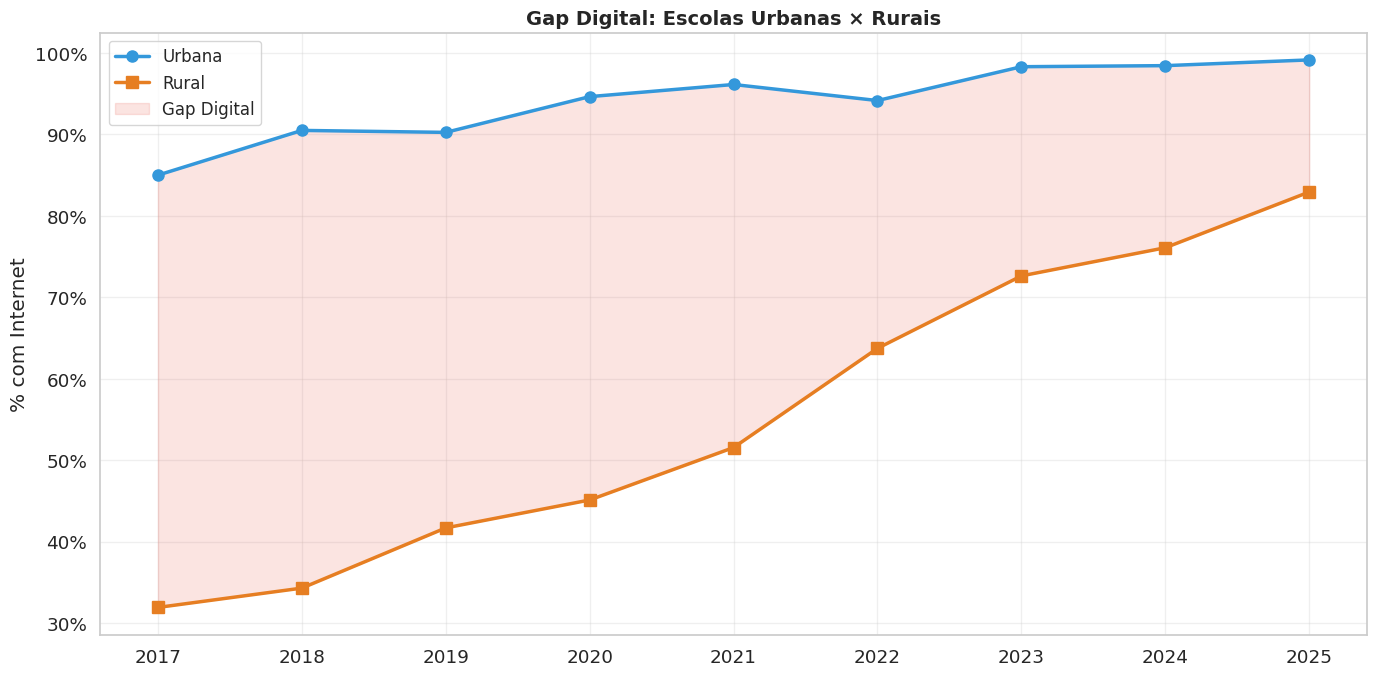

In [ ]:
# G7: Gap Urbano × Rural
if 'DS_LOC' in dfc.columns:
    ur = dfc.groupby(['NU_ANO_CENSO','DS_LOC'])['IN_INTERNET'].mean().reset_index()
    fig, ax = plt.subplots(figsize=(14,7))
    for loc, cor, mk in [('Urbana','#3498db','o'),('Rural','#e67e22','s')]:
        d = ur[ur['DS_LOC']==loc]
        ax.plot(d['NU_ANO_CENSO'], d['IN_INTERNET']*100, f'{mk}-', lw=2.5, label=loc, color=cor, ms=8)
    urb = ur[ur['DS_LOC']=='Urbana'].set_index('NU_ANO_CENSO')['IN_INTERNET']*100
    rur = ur[ur['DS_LOC']=='Rural'].set_index('NU_ANO_CENSO')['IN_INTERNET']*100
    ax.fill_between(rur.index, rur.values, urb.reindex(rur.index).values, alpha=.15, color='#e74c3c', label='Gap Digital')
    ax.set_title('Gap Digital: Escolas Urbanas × Rurais', fontsize=14, fontweight='bold')
    ax.set_ylabel('% com Internet'); ax.legend(fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:.0f}%')); ax.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f'{OUT}/g07_gap.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# G8: Plotly interativo — painel por região
fig = make_subplots(rows=2, cols=3, subplot_titles=[*ordem,'Brasil'],
    specs=[[{'secondary_y':True}]*3]*2)
for i,r in enumerate(ordem):
    ro,co = i//3+1, i%3+1; d = gold_reg[gold_reg['REGIAO']==r]
    fig.add_trace(go.Scatter(x=d['NU_ANO_CENSO'],y=d['PCT_INTERNET']*100,name='Internet',
        line=dict(color=cr[r],width=2),mode='lines+markers',showlegend=(i==0)),row=ro,col=co)
    fig.add_trace(go.Scatter(x=d['NU_ANO_CENSO'],y=d['VL_IDEB'],name='IDEB',
        line=dict(color=cr[r],width=2,dash='dot'),mode='lines+markers',showlegend=(i==0)),
        row=ro,col=co,secondary_y=True)
fig.add_trace(go.Scatter(x=gold_nac['NU_ANO_CENSO'],y=gold_nac['PCT_INTERNET']*100,
    line=dict(color='#34495e',width=3),mode='lines+markers',showlegend=False),row=2,col=3)
fig.add_trace(go.Scatter(x=gold_nac['NU_ANO_CENSO'],y=gold_nac['VL_IDEB'],
    line=dict(color='#34495e',width=3,dash='dot'),mode='lines+markers',showlegend=False),
    row=2,col=3,secondary_y=True)
fig.update_layout(height=700,width=1200,title_text='Conectividade (sólida) × IDEB (pontilhada)')
fig.show()

---
## 8. Forecasting — Projeção até 2035

In [ ]:
# 8a. Modelos ML: Conectividade → IDEB
print('='*60); print('MODELAGEM'); print('='*60)
feats = [f for f in ['PCT_INTERNET','PCT_BL','PCT_LAB','PCT_COMP'] if f in gold.columns]
dm = gold[feats+['VL_IDEB']].dropna(); X,y = dm[feats], dm['VL_IDEB']
print(f'Dados: {len(dm):,} | Features: {feats}')

# OLS
ols = sm.OLS(y, sm.add_constant(X)).fit()
print(ols.summary())

# RF + GB
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
srf = cross_val_score(rf, X, y, cv=5, scoring='r2'); rf.fit(X,y)
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=.1, random_state=42)
sgb = cross_val_score(gb, X, y, cv=5, scoring='r2'); gb.fit(X,y)
print(f'\nRF  R² = {srf.mean():.4f} ± {srf.std():.4f}')
print(f'GB  R² = {sgb.mean():.4f} ± {sgb.std():.4f}')

imp = pd.DataFrame({'Feature':feats,'RF':rf.feature_importances_,'GB':gb.feature_importances_})
display(imp)

MODELAGEM
Dados: 49,357 | Features: ['PCT_INTERNET', 'PCT_BL', 'PCT_LAB', 'PCT_COMP']
                            OLS Regression Results                            
Dep. Variable:                VL_IDEB   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     5070.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:26:02   Log-Likelihood:                -50834.
No. Observations:               49357   AIC:                         1.017e+05
Df Residuals:                   49352   BIC:                         1.017e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

,Feature,RF,GB
0,PCT_INTERNET,0.205333,0.255844
1,PCT_BL,0.083979,0.062290
2,PCT_LAB,0.216643,0.209682
3,PCT_COMP,0.494045,0.472185


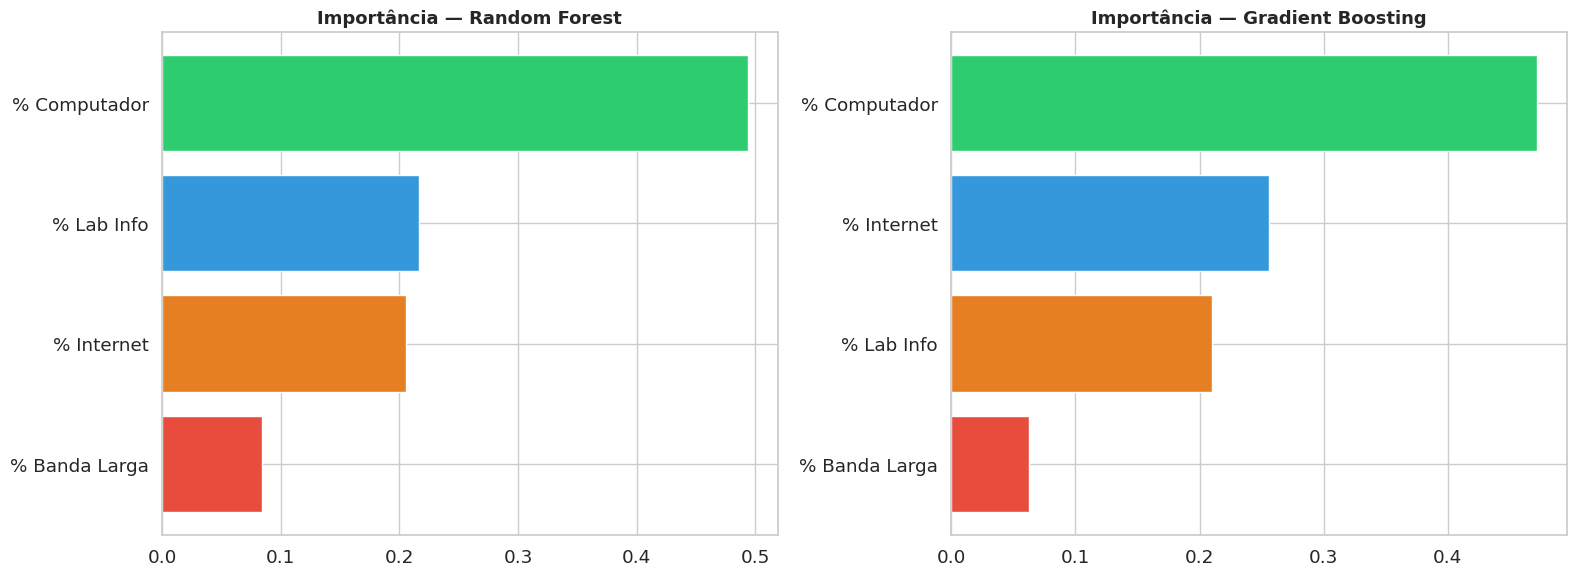

In [ ]:
# G9: Importância das features
lf = {'PCT_INTERNET':'% Internet','PCT_BL':'% Banda Larga','PCT_LAB':'% Lab Info','PCT_COMP':'% Computador'}
fig,(a1,a2) = plt.subplots(1,2,figsize=(16,6))
for ax,col,t in [(a1,'RF','Random Forest'),(a2,'GB','Gradient Boosting')]:
    s = imp.sort_values(col)
    ax.barh([lf.get(f,f) for f in s['Feature']], s[col], color=cfx[:len(feats)])
    ax.set_title(f'Importância — {t}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{OUT}/g09_import.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# 8b. Projeção da conectividade com Prophet
print('='*60); print('PROJEÇÃO PROPHET'); print('='*60)
def projetar(df_nac, col, nome, n=11):
    s = df_nac[['NU_ANO_CENSO',col]].rename(columns={'NU_ANO_CENSO':'ds',col:'y'})
    s['ds'] = pd.to_datetime(s['ds'], format='%Y'); s['cap']=1; s['floor']=0
    m = Prophet(growth='logistic', yearly_seasonality=False, weekly_seasonality=False,
                daily_seasonality=False, changepoint_prior_scale=.5)
    m.fit(s)
    fut = m.make_future_dataframe(periods=n, freq='YS'); fut['cap']=1; fut['floor']=0
    fc = m.predict(fut)
    for c in ['yhat','yhat_lower','yhat_upper']: fc[c] = fc[c].clip(0,1)
    print(f'  {nome} 2035: {fc["yhat"].iloc[-1]:.1%}'); return fc

fc_int = projetar(gold_nac, 'PCT_INTERNET', 'Internet')
fc_bl  = projetar(gold_nac, 'PCT_BL', 'Banda Larga')

PROJEÇÃO PROPHET


INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 6.


  Internet 2035: 99.9%
  Banda Larga 2035: 96.0%


In [ ]:
# 8c. Cenários
print('='*60); print('CENÁRIOS 2025–2035'); print('='*60)
ult = gold_nac.iloc[-1]; ua_r = int(ult['NU_ANO_CENSO'])
cens = {'Conservador':{'tx':.02,'cor':'#e67e22'},'Moderado':{'tx':.04,'cor':'#3498db'},'Acelerado':{'tx':.06,'cor':'#2ecc71'}}
res = []
for nc,p in cens.items():
    for a in range(2025,2036):
        d = a - ua_r
        vals = {f: min(1.0, ult.get(f,0.5)+p['tx']*d) for f in feats}
        ideb_p = gb.predict(pd.DataFrame([vals]))[0]
        res.append({'CEN':nc,'ANO':a,'IDEB_P':ideb_p,**vals})
df_cen = pd.DataFrame(res)

for alvo in [2030,2035]:
    print(f'\n--- {alvo} ---')
    for c in cens:
        r = df_cen[(df_cen['CEN']==c)&(df_cen['ANO']==alvo)].iloc[0]
        print(f'  {c:14s}: Internet={r["PCT_INTERNET"]:.0%}  IDEB={r["IDEB_P"]:.2f}')

CENÁRIOS 2025–2035

--- 2030 ---
  Conservador   : Internet=100%  IDEB=5.42
  Moderado      : Internet=100%  IDEB=5.59
  Acelerado     : Internet=100%  IDEB=5.63

--- 2035 ---
  Conservador   : Internet=100%  IDEB=5.59
  Moderado      : Internet=100%  IDEB=6.09
  Acelerado     : Internet=100%  IDEB=5.74


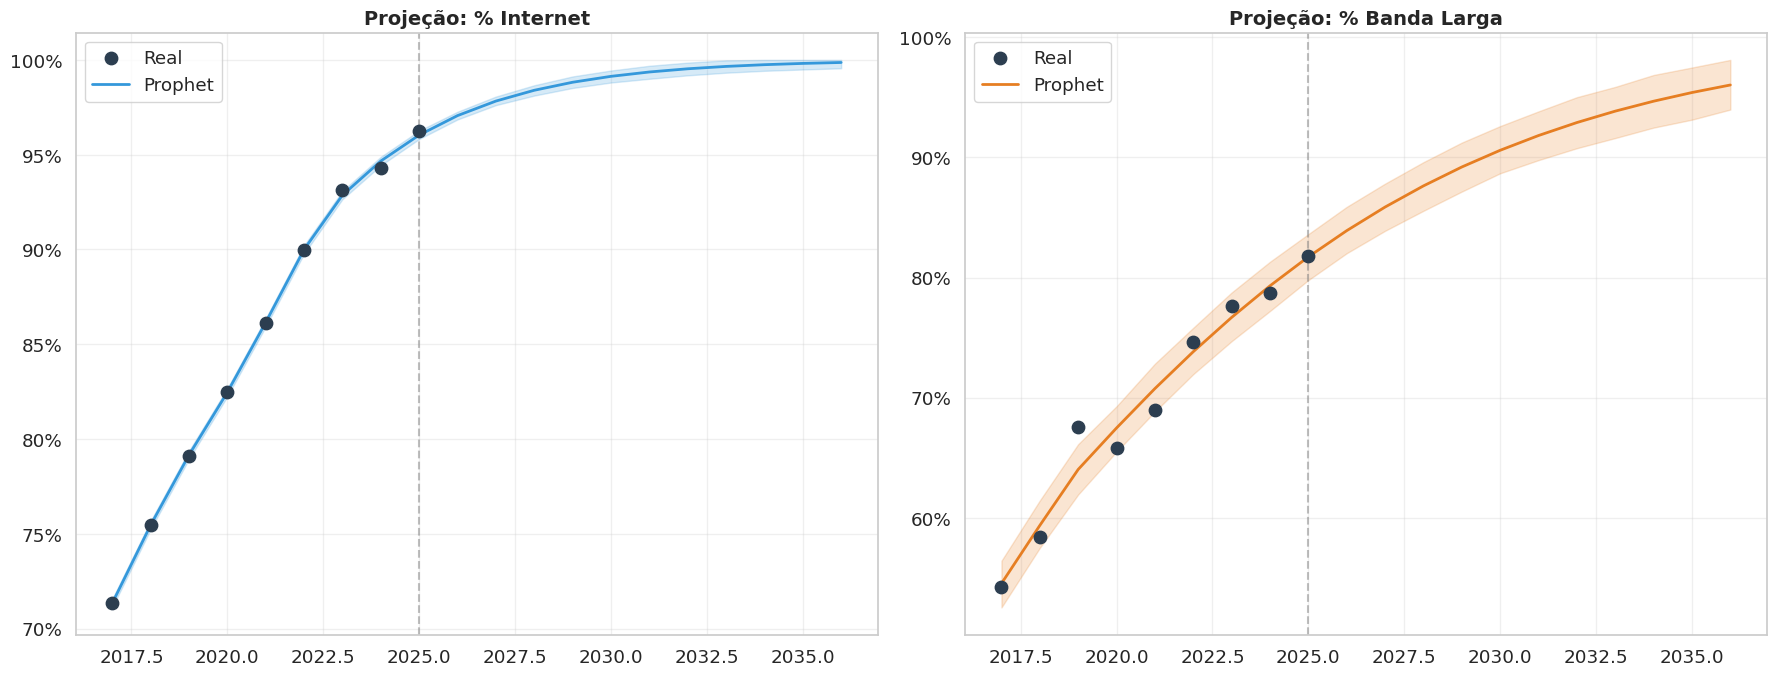

In [ ]:
# G10: Projeção Prophet
fig,(a1,a2) = plt.subplots(1,2,figsize=(18,7))
for ax,fc,col,nome,cor in [(a1,fc_int,'PCT_INTERNET','Internet','#3498db'),(a2,fc_bl,'PCT_BL','Banda Larga','#e67e22')]:
    ax.scatter(gold_nac['NU_ANO_CENSO'], gold_nac[col]*100, color='#2c3e50', s=80, zorder=5, label='Real')
    ax.plot(fc['ds'].dt.year, fc['yhat']*100, color=cor, lw=2, label='Prophet')
    ax.fill_between(fc['ds'].dt.year, fc['yhat_lower']*100, fc['yhat_upper']*100, color=cor, alpha=.2)
    ax.axvline(ua_r, color='gray', ls='--', alpha=.5)
    ax.set_title(f'Projeção: % {nome}', fontsize=14, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'{x:.0f}%'))
    ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/g10_prophet.png', dpi=150, bbox_inches='tight'); plt.show()

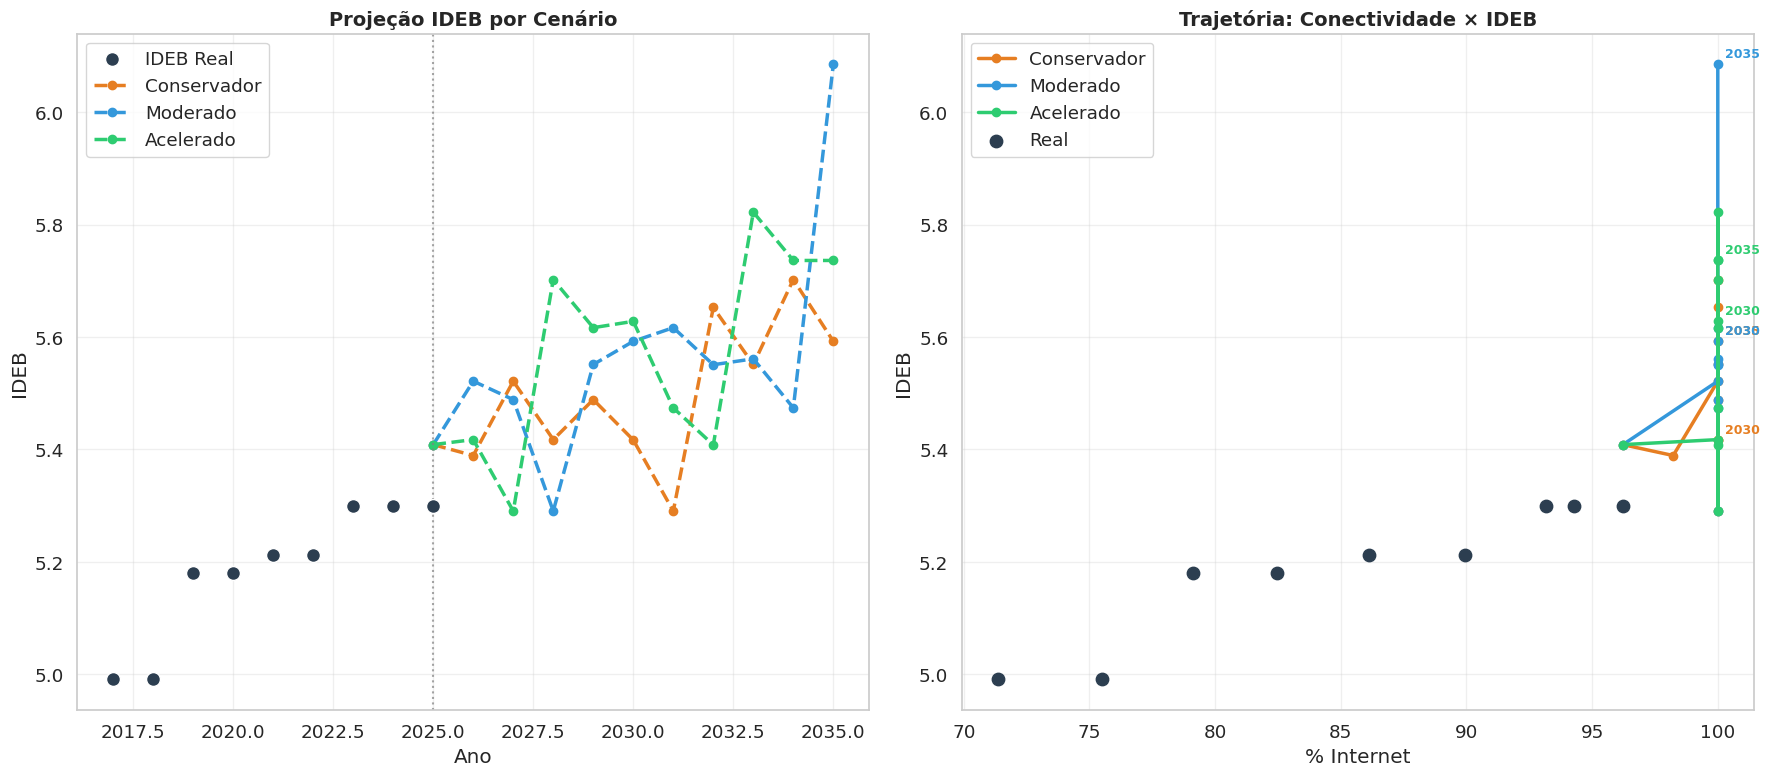

In [ ]:
# G11: Cenários IDEB
fig,(a1,a2) = plt.subplots(1,2,figsize=(18,8))
a1.scatter(gold_nac['NU_ANO_CENSO'], gold_nac['VL_IDEB'], color='#2c3e50', s=100, zorder=5,
           label='IDEB Real', edgecolors='white')
for c in cens:
    d = df_cen[df_cen['CEN']==c]
    a1.plot(d['ANO'], d['IDEB_P'], 'o--', lw=2.5, color=cens[c]['cor'], label=c)
a1.axvline(ua_r, color='gray', ls=':', alpha=.7)
a1.set_title('Projeção IDEB por Cenário', fontsize=14, fontweight='bold')
a1.set_xlabel('Ano'); a1.set_ylabel('IDEB'); a1.legend(); a1.grid(alpha=.3)

for c in cens:
    d = df_cen[df_cen['CEN']==c]
    a2.plot(d['PCT_INTERNET']*100, d['IDEB_P'], 'o-', lw=2.5, color=cens[c]['cor'], label=c)
    for yr in [2030,2035]:
        rw = d[d['ANO']==yr]
        if len(rw): a2.annotate(str(yr), (rw['PCT_INTERNET'].values[0]*100, rw['IDEB_P'].values[0]),
            fontsize=9, fontweight='bold', color=cens[c]['cor'], xytext=(5,5), textcoords='offset points')
a2.scatter(gold_nac['PCT_INTERNET']*100, gold_nac['VL_IDEB'], color='#2c3e50', s=80, zorder=5, label='Real')
a2.set_title('Trajetória: Conectividade × IDEB', fontsize=14, fontweight='bold')
a2.set_xlabel('% Internet'); a2.set_ylabel('IDEB'); a2.legend(); a2.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{OUT}/g11_cenarios.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# G12: Dashboard final Plotly
fig = make_subplots(2,2, subplot_titles=['Cenários Conectividade','Cenários IDEB','Impacto Marginal','Comparativo 2035'],
    specs=[[{},{}],[{},{'type':'bar'}]])
ch = {c:cens[c]['cor'] for c in cens}
for c in ch:
    d = df_cen[df_cen['CEN']==c]
    fig.add_trace(go.Scatter(x=d['ANO'],y=d['PCT_INTERNET']*100,name=c,line=dict(color=ch[c],width=2.5),mode='lines+markers'),row=1,col=1)
    fig.add_trace(go.Scatter(x=d['ANO'],y=d['IDEB_P'],name=f'{c}',line=dict(color=ch[c],width=2.5,dash='dot'),mode='lines+markers',showlegend=False),row=1,col=2)
xm = np.linspace(0,1,100)
ym = [gb.predict(pd.DataFrame([[v,v*.9,v*.5,v*.6]],columns=feats))[0] for v in xm]
fig.add_trace(go.Scatter(x=xm*100,y=ym,line=dict(color='#8e44ad',width=3),showlegend=False),row=2,col=1)
d35 = df_cen[df_cen['ANO']==2035]
fig.add_trace(go.Bar(x=d35['CEN'],y=d35['IDEB_P'],marker_color=[ch[c] for c in d35['CEN']],
    text=d35['IDEB_P'].round(2),textposition='outside',showlegend=False),row=2,col=2)
fig.update_layout(height=800,width=1200,title_text='Dashboard Forecasting: Conectividade → Educação (2035)')
fig.show()

---
## 9. Conclusões

In [ ]:
ci = gold['PCT_INTERNET'].corr(gold['VL_IDEB'])
cs = gold['SCORE_CONECT_MED'].corr(gold['VL_IDEB'])
print('╔'+('═'*68)+'╗')
print('║'+' RESULTADOS — DADOS REAIS INEP '.center(68)+'║')
print('╠'+('═'*68)+'╣')
print(f'║  Censo Escolar: {len(anos_ok)} anos | {len(df_censo):,} registros'.ljust(69)+'║')
print(f'║  IDEB: {len(df_ideb):,} registros (AI + AF)'.ljust(69)+'║')
print(f'║  Camada Ouro: {gold["CO_MUNICIPIO"].nunique():,} municípios'.ljust(69)+'║')
print(f'║'.ljust(69)+'║')
print(f'║  CORRELAÇÕES'.ljust(69)+'║')
print(f'║    Internet × IDEB:  r = {ci:+.3f}'.ljust(69)+'║')
print(f'║    Score Conect. × IDEB: r = {cs:+.3f}'.ljust(69)+'║')
print(f'║'.ljust(69)+'║')
print(f'║  ML (R² cross-validated)'.ljust(69)+'║')
print(f'║    OLS:               {ols.rsquared:.4f}'.ljust(69)+'║')
print(f'║    Random Forest:     {srf.mean():.4f} ± {srf.std():.4f}'.ljust(69)+'║')
print(f'║    Gradient Boosting: {sgb.mean():.4f} ± {sgb.std():.4f}'.ljust(69)+'║')
print(f'║'.ljust(69)+'║')
print(f'║  PROJEÇÕES 2035'.ljust(69)+'║')
for c in cens:
    r = df_cen[(df_cen['CEN']==c)&(df_cen['ANO']==2035)].iloc[0]
    print(f'║    {c:14s}: Internet {r["PCT_INTERNET"]:.0%} → IDEB {r["IDEB_P"]:.2f}'.ljust(69)+'║')
print('╠'+('═'*68)+'╣')
print('║  CONCLUSÃO: Conectividade escolar apresenta correlação'.ljust(69)+'║')
print('║  POSITIVA com o IDEB. O investimento em conectividade'.ljust(69)+'║')
print('║  pode contribuir para melhorar a qualidade da educação.'.ljust(69)+'║')
print('╚'+('═'*68)+'╝')

╔════════════════════════════════════════════════════════════════════╗
║                   RESULTADOS — DADOS REAIS INEP                    ║
╠════════════════════════════════════════════════════════════════════╣
║  Censo Escolar: 9 anos | 1,639,642 registros                       ║
║  IDEB: 52,864 registros (AI + AF)                                  ║
║  Camada Ouro: 5,564 municípios                                     ║
║                                                                    ║
║  CORRELAÇÕES                                                       ║
║    Internet × IDEB:  r = +0.473                                    ║
║    Score Conect. × IDEB: r = +0.527                                ║
║                                                                    ║
║  ML (R² cross-validated)                                           ║
║    OLS:               0.2912                                       ║
║    Random Forest:     -0.3348 ± 0.3889                             ║
║    G

In [ ]:
df_cen.to_csv(f'{OUT}/cenarios_2035.csv', index=False)
gold.to_csv(f'{OUT}/gold.csv', index=False)
gold_nac.to_csv(f'{OUT}/serie_nacional.csv', index=False)
print('📁 Exportado:'); [print(f'  📄 {f}') for f in sorted(os.listdir(OUT))]

📁 Exportado:
  📄 cenarios_2035.csv
  📄 g01_evolucao.png
  📄 g02_regiao.png
  📄 g03_scatter.png
  📄 g04_heatmap.png
  📄 g05_box.png
  📄 g06_heatmap_tempo.png
  📄 g07_gap.png
  📄 g09_import.png
  📄 g10_prophet.png
  📄 g11_cenarios.png
  📄 gold.csv
  📄 serie_nacional.csv


[None, None, None, None, None, None, None, None, None, None, None, None, None]